# Day 08. Exercise 05
# Clustering

## 0. Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [27]:
df = pd.read_csv('../data/regression.csv')

In [28]:
df = df[['num_commits', 'AVG(diff)']]

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [29]:
def optimize_clustering(model_class, params, param_name, param_range, X):
    scores = []
    models = []
    
    for value in param_range:
        if param_name == 'n_clusters':
            model = model_class(n_clusters=value, **params)
        elif param_name == 'eps':
            model = model_class(eps=value, **params)
        elif param_name == 'min_samples':
            model = model_class(min_samples=value, **params)
        else:
            raise ValueError("Unsupported parameter")
        
        labels = model.fit_predict(X)
        if len(set(labels)) > 1:
            score = silhouette_score(X, labels)
        else:
            score = -1
        scores.append(score)
        models.append(model)
    
    best_idx = np.argmax(scores)
    best_value = param_range[best_idx]
    best_model = models[best_idx]
    best_labels = best_model.fit_predict(X)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(param_range, scores, 'bo-')
    ax1.set_xlabel(param_name)
    ax1.set_ylabel('Silhouette Score')
    ax1.set_title(f'Silhouette Score vs {param_name}')
    ax1.axvline(x=best_value, color='r', linestyle='--')
    
    ax2.scatter(X.iloc[:, 0], X.iloc[:, 1], c=best_labels, cmap='viridis')
    ax2.set_xlabel('Number of Commits')
    ax2.set_ylabel('Average Difference')
    ax2.set_title(f'Clustering with {param_name}={best_value}')
    
    plt.show()
    
    return best_value, scores[best_idx]

## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [30]:
kmeans = KMeans(n_clusters=3, random_state=21)
labels_kmeans = kmeans.fit_predict(df)
print(f"KMeans Silhouette Score (n_clusters=3): {silhouette_score(df, labels_kmeans)}")

KMeans Silhouette Score (n_clusters=3): 0.4454402135233297


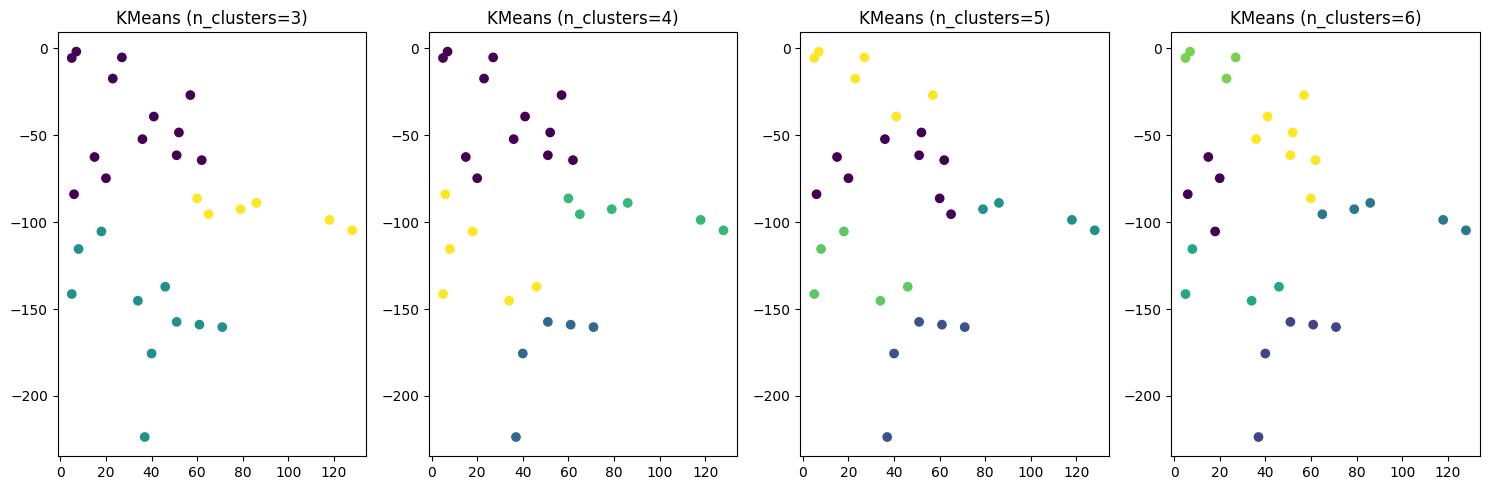

In [31]:
plt.figure(figsize=(15, 5))
for i, n_clusters in enumerate([3, 4, 5, 6]):
    kmeans = KMeans(n_clusters=n_clusters, random_state=21)
    labels = kmeans.fit_predict(df)
    plt.subplot(1, 4, i+1)
    plt.scatter(df['num_commits'], df['AVG(diff)'], c=labels, cmap='viridis')
    plt.title(f'KMeans (n_clusters={n_clusters})')
plt.tight_layout()
plt.show()

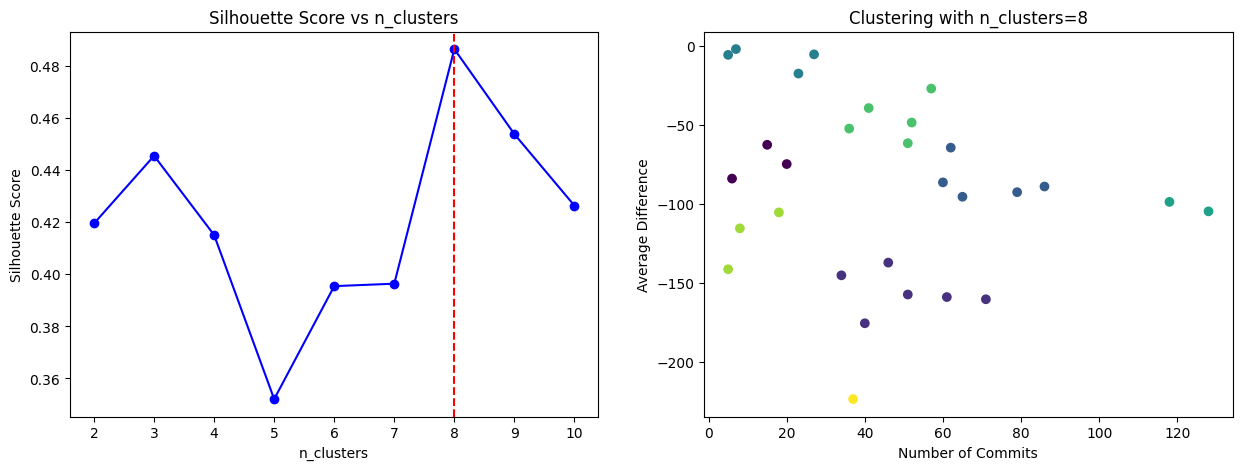

Best n_clusters for KMeans: 8, Score: 0.48638087320227846


In [32]:
best_n, score_kmeans = optimize_clustering(
    KMeans, {'random_state': 21}, 'n_clusters', range(2, 11), df
)
print(f"Best n_clusters for KMeans: {best_n}, Score: {score_kmeans}")

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [33]:
dbscan = DBSCAN(eps=20, min_samples=2)
labels_dbscan = dbscan.fit_predict(df)
print(f"DBSCAN Silhouette Score (eps=20, min_samples=2): {silhouette_score(df, labels_dbscan)}")

DBSCAN Silhouette Score (eps=20, min_samples=2): 0.38339641455696616


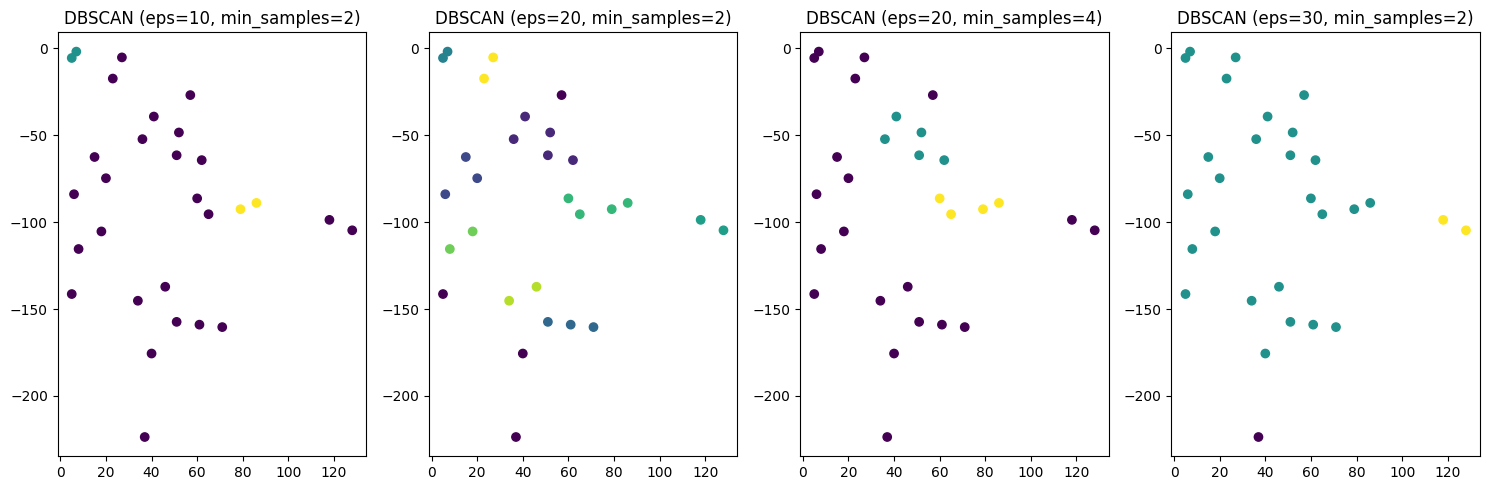

In [34]:
plt.figure(figsize=(15, 5))
params = [(10, 2), (20, 2), (20, 4), (30, 2)]
for i, (eps, min_samples) in enumerate(params):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(df)
    plt.subplot(1, 4, i+1)
    plt.scatter(df['num_commits'], df['AVG(diff)'], c=labels, cmap='viridis')
    plt.title(f'DBSCAN (eps={eps}, min_samples={min_samples})')
plt.tight_layout()
plt.show()

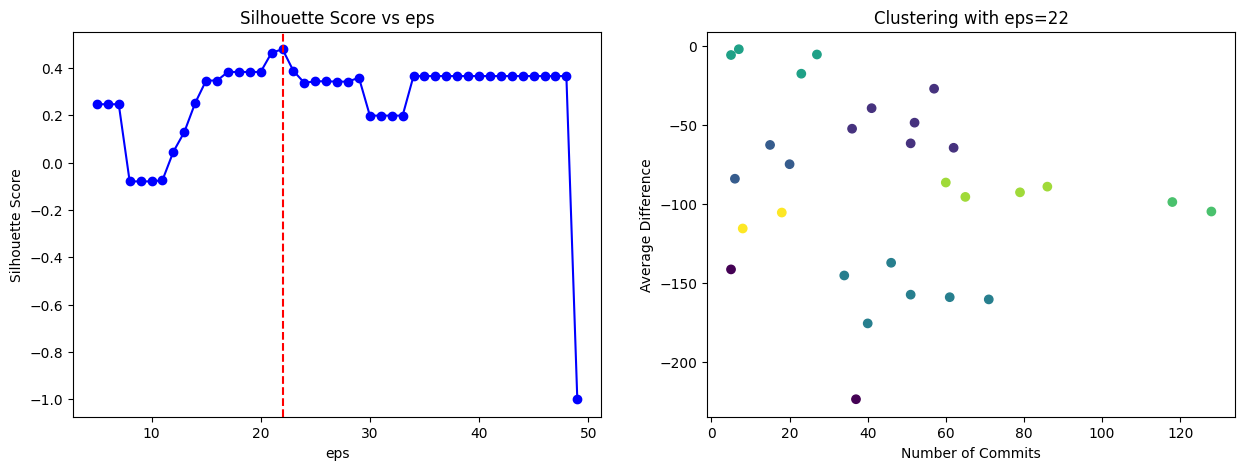

Best eps for DBSCAN: 22, Score: 0.4794129092034348


In [35]:
best_eps, score_dbscan_eps = optimize_clustering(
    DBSCAN, {'min_samples': 2}, 'eps', np.arange(5, 50, 1), df
)
print(f"Best eps for DBSCAN: {best_eps}, Score: {score_dbscan_eps}")

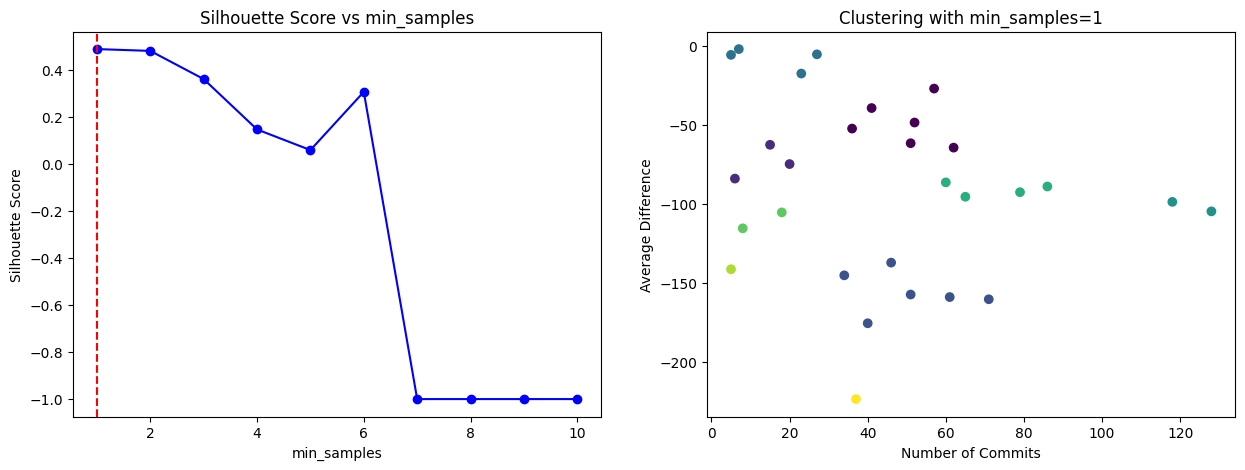

Best min_samples for DBSCAN: 1, Score: 0.48713041554757475


In [36]:
best_min_samples, score_dbscan_min = optimize_clustering(
    DBSCAN, {'eps': best_eps}, 'min_samples', range(1, 11), df
)
print(f"Best min_samples for DBSCAN: {best_min_samples}, Score: {score_dbscan_min}")

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [37]:
agg = AgglomerativeClustering(n_clusters=5)
labels_agg = agg.fit_predict(df)
print(f"Agglomerative Silhouette Score (n_clusters=5): {silhouette_score(df, labels_agg)}")

Agglomerative Silhouette Score (n_clusters=5): 0.46383015199381467


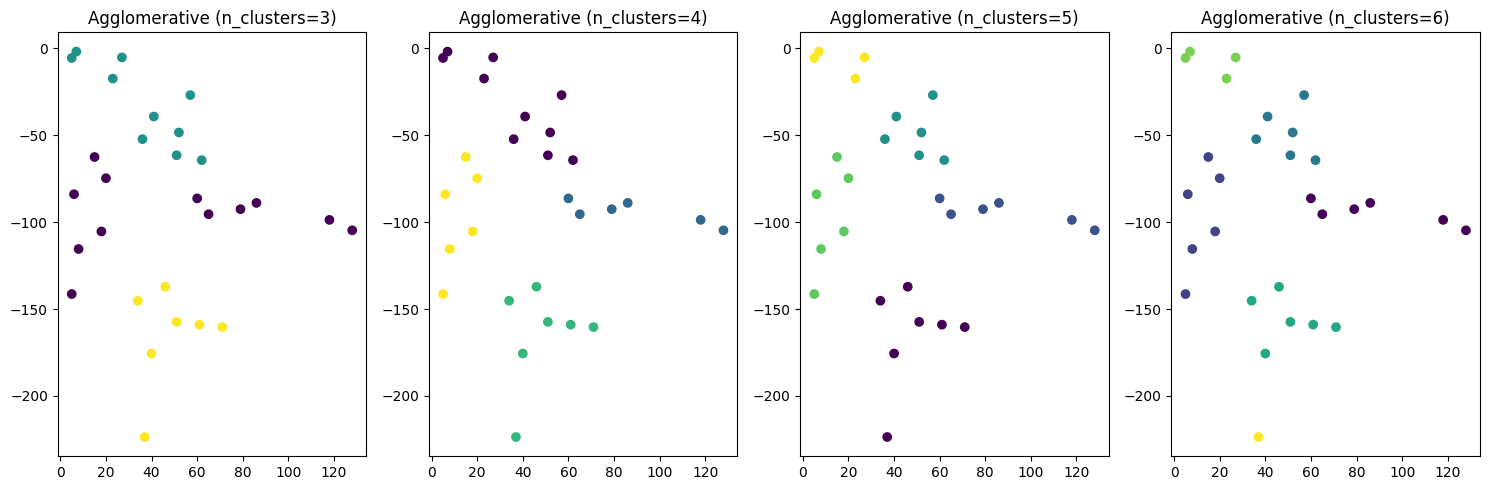

In [38]:
plt.figure(figsize=(15, 5))
for i, n_clusters in enumerate([3, 4, 5, 6]):
    agg = AgglomerativeClustering(n_clusters=n_clusters)
    labels = agg.fit_predict(df)
    plt.subplot(1, 4, i+1)
    plt.scatter(df['num_commits'], df['AVG(diff)'], c=labels, cmap='viridis')
    plt.title(f'Agglomerative (n_clusters={n_clusters})')
plt.tight_layout()
plt.show()

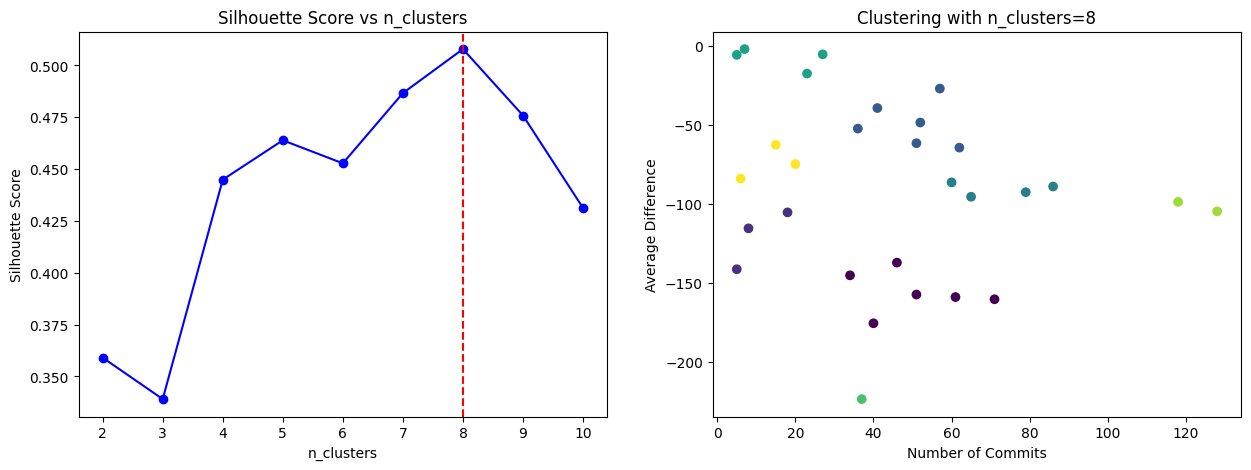

Best n_clusters for AgglomerativeClustering: 8, Score: 0.5077985556562201


In [39]:
best_n_agg, score_agg = optimize_clustering(
    AgglomerativeClustering, {}, 'n_clusters', range(2, 11), df
)
print(f"Best n_clusters for AgglomerativeClustering: {best_n_agg}, Score: {score_agg}")

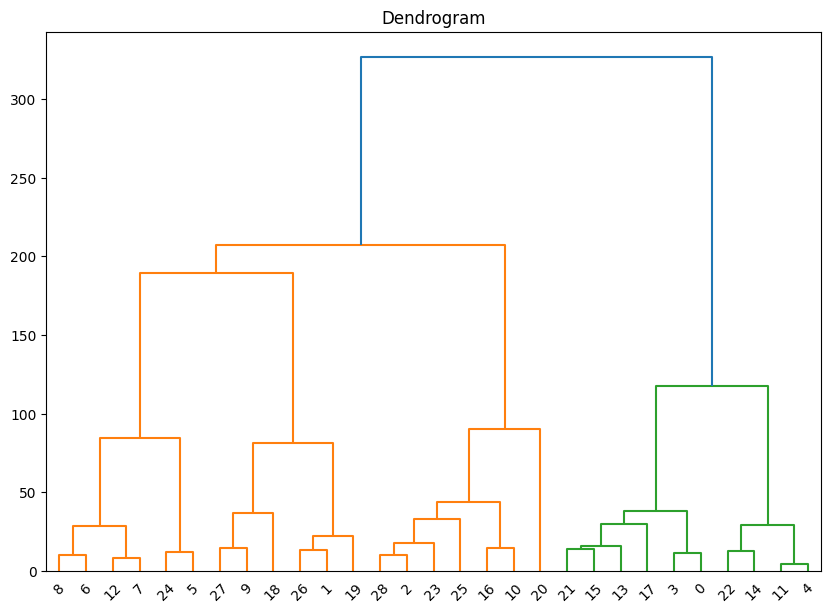

In [40]:
linked = linkage(df, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', labels=range(len(df)), distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram')
plt.show()